In [1]:
import os
import sys
# current_dir = os.path.dirname(os.path.abspath(__file__))
# parent_dir = os.path.dirname(current_dir)
sys.path.append("../")
import pandas as pd
import numpy as np
from collections import Counter
from statistics import mode
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
from datetime import datetime, timedelta
from Config.Config import MAIN_PATH, ETF_DATA_PATH
from Utils.main import PrintUtils, FileUtils, JsonUtils, TextUtils
THREAD_SAFE_PRINT = PrintUtils.THREAD_SAFE_PRINT
Check_Folder = FileUtils.Check_Folder
Check_File = FileUtils.Check_File
Dict_to_JsonFile = JsonUtils.Dict_to_JsonFile
JsonFile_to_Dict = JsonUtils.JsonFile_to_Dict
Format_Num = TextUtils.Format_Num

plt.rcParams['font.sans-serif'] = ['SimHei']  # Show Chinese labels
plt.rcParams['axes.unicode_minus'] = False    # Show negative sign
# sns.set(style="whitegrid", font='SimHei')   # Seaborn

Begin_date = "20140201"
End_date = "20251231"

In [2]:
def Get_Most_N_Common_Elements(input_list, N=1):
    """
    - Get the N most common elements from a list.
    - input_list: list, input list of elements
    - N: int, number of most common elements to return
    - return: list of elements
    """
    element_counts = Counter(input_list)
    most_common_elements = element_counts.most_common(N)
    return [element for element, _ in most_common_elements]

# Example usage:
# input_list = ['apple', 'banana', 'apple', 'orange', 'banana', 'apple']
# Get_Most_N_Common_Elements(input_list, N=2)

# Load Index Data

In [3]:
SW_SECTOR_PATH_MAPPING = JsonFile_to_Dict(ETF_DATA_PATH + "SW-SECTOR-PATH-MAPPING.json")
BENCHMARK_PATH_MAPPING = JsonFile_to_Dict(ETF_DATA_PATH + "BENCHMARK-PATH-MAPPING.json")
SW_SECTOR_LEVEL_1_List = [industry for industry in SW_SECTOR_PATH_MAPPING.keys() if len(industry.split('-')) == 1]
BENCHMARK_List = [benchmark for benchmark in BENCHMARK_PATH_MAPPING.keys()]

In [4]:
def Get_Index_ROI(industry_name, sw_sector_path_map, begin_date, end_date):
    SW_Real_Estate_DF = pd.read_csv(ETF_DATA_PATH + sw_sector_path_map[industry_name])
    # Note the date format in the CSV file is YYYY-MM-DD
    date_range = pd.date_range(start=begin_date, end=end_date)
    date_range_str = date_range.strftime("%Y-%m-%d").tolist()
    SW_Real_Estate_DF_Filtered = SW_Real_Estate_DF[SW_Real_Estate_DF['date'].isin(date_range_str)].reset_index(drop=True)[['date', 'open', 'close']]
    
    # ROI Calculation
    # For the first day, ROI = (close - open) / open
    # For subsequent days, ROI = (current_close - previous_close) / previous_close
    SW_Real_Estate_DF_Filtered_ROI_DF = SW_Real_Estate_DF_Filtered.copy()
    First_day_ROI = (SW_Real_Estate_DF_Filtered_ROI_DF.loc[0, 'close'] - SW_Real_Estate_DF_Filtered_ROI_DF.loc[0, 'open']) / SW_Real_Estate_DF_Filtered_ROI_DF.loc[0, 'open']
    SW_Real_Estate_DF_Filtered_ROI_DF['ROI'] = SW_Real_Estate_DF_Filtered_ROI_DF['close'].pct_change().fillna(First_day_ROI)
    SW_Real_Estate_DF_Filtered_ROI_DF = SW_Real_Estate_DF_Filtered_ROI_DF[['date', 'ROI']]
    
    # Ensure every date in the range has data
    # If missing, fill with 0 ROI
    SW_Real_Estate_DF_Filtered_ROI_DF.set_index('date', inplace=True)
    SW_Real_Estate_DF_Filtered_ROI = SW_Real_Estate_DF_Filtered_ROI_DF.reindex(date_range_str, fill_value=0).reset_index().rename(columns={'index': 'date'})
    SW_Real_Estate_DF_Filtered_ROI["PnL"] = (1 + SW_Real_Estate_DF_Filtered_ROI['ROI']).cumprod()
    
    # Get the independent PnL series (suppose begin with 1 unit of currency)
    # SW_Real_Estate_PnL_List = list((1 + SW_Real_Estate_DF_Filtered_ROI['ROI']).cumprod())
    return SW_Real_Estate_DF_Filtered_ROI

def Get_Benchmark_ROI(benchmark_name, benchmark_path_map, begin_date, end_date):
    Benchmark_DF = pd.read_csv(ETF_DATA_PATH + benchmark_path_map[benchmark_name])
    # Note the date format in the CSV file is YYYY-MM-DD
    date_range = pd.date_range(start=begin_date, end=end_date)
    date_range_str = date_range.strftime("%Y-%m-%d").tolist()
    Benchmark_DF_Filtered = Benchmark_DF[Benchmark_DF['date'].isin(date_range_str)].reset_index(drop=True)[['date', 'open', 'close']]
    
    # ROI Calculation
    # For the first day, ROI = (close - open) / open
    # For subsequent days, ROI = (current_close - previous_close) / previous_close
    Benchmark_DF_Filtered_ROI_DF = Benchmark_DF_Filtered.copy()
    First_day_ROI = (Benchmark_DF_Filtered_ROI_DF.loc[0, 'close'] - Benchmark_DF_Filtered_ROI_DF.loc[0, 'open']) / Benchmark_DF_Filtered_ROI_DF.loc[0, 'open']
    Benchmark_DF_Filtered_ROI_DF['ROI'] = Benchmark_DF_Filtered_ROI_DF['close'].pct_change().fillna(First_day_ROI)
    Benchmark_DF_Filtered_ROI_DF = Benchmark_DF_Filtered_ROI_DF[['date', 'ROI']]
    
    # Ensure every date in the range has data
    # If missing, fill with 0 ROI
    Benchmark_DF_Filtered_ROI_DF.set_index('date', inplace=True)
    Benchmark_DF_Filtered_ROI = Benchmark_DF_Filtered_ROI_DF.reindex(date_range_str, fill_value=0).reset_index().rename(columns={'index': 'date'})
    Benchmark_DF_Filtered_ROI["PnL"] = (1 + Benchmark_DF_Filtered_ROI['ROI']).cumprod()
    
    # Get the independent PnL series (suppose begin with 1 unit of currency)
    # Benchmark_PnL_List = list((1 + Benchmark_DF_Filtered_ROI['ROI']).cumprod())
    return Benchmark_DF_Filtered_ROI

In [5]:
# Get all level 1 industry PnL data
industry_level1_pnl_all_df = pd.DataFrame()
for industry in SW_SECTOR_PATH_MAPPING:
    if len(industry.split("-")) == 1: # get 1 level industry
        industry_roi_pnl_df = Get_Index_ROI(
            industry_name=industry, sw_sector_path_map=SW_SECTOR_PATH_MAPPING, 
            begin_date=Begin_date, end_date=End_date)
        industry_pnl_df = industry_roi_pnl_df[["date", "PnL"]].rename(columns={"PnL": industry})
        # Combine dfs
        if industry_level1_pnl_all_df.empty:
            industry_level1_pnl_all_df = industry_pnl_df
        else:
            industry_level1_pnl_all_df = pd.merge(industry_level1_pnl_all_df, industry_pnl_df, on="date", how="inner")

industry_level1_pnl_all_df["date"] = pd.to_datetime(industry_level1_pnl_all_df["date"])

# Get all level 1 industry ROI data
industry_level1_roi_all_df = pd.DataFrame()
for industry in SW_SECTOR_PATH_MAPPING:
    if len(industry.split("-")) == 1: # get 1 level industry
        industry_roi_pnl_df = Get_Index_ROI(
            industry_name=industry, sw_sector_path_map=SW_SECTOR_PATH_MAPPING, 
            begin_date=Begin_date, end_date=End_date)
        industry_roi_df = industry_roi_pnl_df[["date", "ROI"]].rename(columns={"ROI": industry})
        # Combine dfs
        if industry_level1_roi_all_df.empty:
            industry_level1_roi_all_df = industry_roi_df
        else:
            industry_level1_roi_all_df = pd.merge(industry_level1_roi_all_df, industry_roi_df, on="date", how="inner")

industry_level1_roi_all_df["date"] = pd.to_datetime(industry_level1_roi_all_df["date"])

# Get all benchmark PnL data
benchmark_pnl_all_df = pd.DataFrame()
for benchmark in BENCHMARK_PATH_MAPPING:
    benchmark_roi_pnl_df = Get_Benchmark_ROI(
        benchmark_name=benchmark, benchmark_path_map=BENCHMARK_PATH_MAPPING, 
        begin_date=Begin_date, end_date=End_date)
    benchmark_pnl_df = benchmark_roi_pnl_df[["date", "PnL"]].rename(columns={"PnL": benchmark})
    # Combine dfs
    if benchmark_pnl_all_df.empty:
        benchmark_pnl_all_df = benchmark_pnl_df
    else:
        benchmark_pnl_all_df = pd.merge(benchmark_pnl_all_df, benchmark_pnl_df, on="date", how="inner")

benchmark_pnl_all_df["date"] = pd.to_datetime(benchmark_pnl_all_df["date"])

# Get all benchmark ROI data
benchmark_roi_all_df = pd.DataFrame()
for benchmark in BENCHMARK_PATH_MAPPING:
    benchmark_roi_pnl_df = Get_Benchmark_ROI(
        benchmark_name=benchmark, benchmark_path_map=BENCHMARK_PATH_MAPPING, 
        begin_date=Begin_date, end_date=End_date)
    benchmark_roi_df = benchmark_roi_pnl_df[["date", "ROI"]].rename(columns={"ROI": benchmark})
    # Combine dfs
    if benchmark_roi_all_df.empty:
        benchmark_roi_all_df = benchmark_roi_df
    else:
        benchmark_roi_all_df = pd.merge(benchmark_roi_all_df, benchmark_roi_df, on="date", how="inner")

benchmark_roi_all_df["date"] = pd.to_datetime(benchmark_roi_all_df["date"])

In [6]:
industry_level1_pnl_all_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2014-02-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,2014-02-03,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,2014-02-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,2014-02-05,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,1.715683,2.543774,1.886786,3.646179,3.640535,2.628962,3.183033,3.767585,1.040749,...,2.686503,2.128065,1.925514,1.826873,0.804521,3.437520,2.783368,1.030826,0.899064,0.532874
4348,2025-12-28,1.715683,2.543774,1.886786,3.646179,3.640535,2.628962,3.183033,3.767585,1.040749,...,2.686503,2.128065,1.925514,1.826873,0.804521,3.437520,2.783368,1.030826,0.899064,0.532874
4349,2025-12-29,1.727911,2.533052,1.880705,3.574996,3.653478,2.639730,3.175111,3.727575,1.037642,...,2.656167,2.130792,1.953014,1.829695,0.802817,3.422588,2.786239,1.046049,0.891909,0.528690
4350,2025-12-30,1.737050,2.544412,1.873469,3.621696,3.672000,2.675371,3.205638,3.704523,1.039347,...,2.651825,2.158252,1.942936,1.832806,0.809192,3.435247,2.777284,1.073566,0.885066,0.529579


In [7]:
industry_level1_roi_all_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2014-02-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2014-02-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2014-02-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2014-02-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4348,2025-12-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4349,2025-12-29,0.007127,-0.004215,-0.003223,-0.019522,0.003555,0.004096,-0.002489,-0.010620,-0.002985,...,-0.011292,0.001281,0.014282,0.001545,-0.002118,-0.004344,0.001032,0.014767,-0.007958,-0.007851
4350,2025-12-30,0.005289,0.004485,-0.003848,0.013063,0.005070,0.013502,0.009614,-0.006184,0.001643,...,-0.001635,0.012887,-0.005160,0.001700,0.007941,0.003699,-0.003214,0.026306,-0.007672,0.001681


In [8]:
benchmark_pnl_all_df

,date,HS300,CSI500,CSI1000
0,2014-02-01,1.000000,1.000000,1.000000
1,2014-02-02,1.000000,1.000000,1.000000
2,2014-02-03,1.000000,1.000000,1.000000
3,2014-02-04,1.000000,1.000000,1.000000
4,2014-02-05,1.000000,1.000000,1.000000
...,...,...,...,...
4347,2025-12-27,2.129177,1.929897,1.622105
4348,2025-12-28,2.129177,1.929897,1.622105
4349,2025-12-29,2.121008,1.922594,1.619680
4350,2025-12-30,2.126453,1.929922,1.620350


In [9]:
benchmark_roi_all_df

,date,HS300,CSI500,CSI1000
0,2014-02-01,0.000000,0.000000,0.000000
1,2014-02-02,0.000000,0.000000,0.000000
2,2014-02-03,0.000000,0.000000,0.000000
3,2014-02-04,0.000000,0.000000,0.000000
4,2014-02-05,0.000000,0.000000,0.000000
...,...,...,...,...
4347,2025-12-27,0.000000,0.000000,0.000000
4348,2025-12-28,0.000000,0.000000,0.000000
4349,2025-12-29,-0.003837,-0.003784,-0.001495
4350,2025-12-30,0.002567,0.003811,0.000414


# AD Count Analysis

In [10]:
def AD_Count_Analysis(Folder_Path, Begin_date="20150101", End_date="20251231", Log_File_Path=""):
    """
    - Analyze the number of ads and ad blocks in the given year and date range
    - Return a dictionary with date as key and counts as values
    - The output dictionary format:
        {"YYYYMMDD": {"total_ads": int, "total_full_ads": int, "total_ad_blocks": int}, ...}
    - Each image has its own Text_Dict, which contains OCR content/length and summary content
    - For OCR content, the key format are f"OCR_{Model_Name}" and f"OCR_{Model_Name}_Len"
    """
    Begin_Year = Begin_date[:4]
    End_Year = End_date[:4]
    Filter_Dict = {}
    Missing_Filter_Files = False
    for YEAR in range(int(Begin_Year), int(End_Year) + 1):
        AD_PATH = Folder_Path + f"{YEAR}_AD/"
        Filter_Path = f"{AD_PATH}{YEAR}_Shape_Dict_Final_Filter_Outlier.json"
        Filter_File_Bool = Check_File(File_Path=Filter_Path, Create_New=False)
        if not Filter_File_Bool: 
            THREAD_SAFE_PRINT("Text Recognition", f"{Filter_Path} does not exist! Please run 'Check_Duplicated_Images'", Log_File_Path)
            Missing_Filter_Files = True
        Filter_List = JsonFile_to_Dict(filename=Filter_Path, Log_File_Path=Log_File_Path).get("Final_Filter", [])
        if not Filter_List: 
            THREAD_SAFE_PRINT("Text Recognition", f"{Filter_Path} is empty! Please run 'Check_Duplicated_Images'", Log_File_Path)
            Missing_Filter_Files = True
        Filter_Dict[str(YEAR)] = Filter_List
    if Missing_Filter_Files: return {}
    start_date = datetime(int(Begin_Year), int(Begin_date[4:6]), int(Begin_date[6:]))
    end_date = datetime(int(End_Year), int(End_date[4:6]), int(End_date[6:]))
    THREAD_SAFE_PRINT("Text Recognition", f"Begin date: {Begin_date}, End date: {End_date}", Log_File_Path)
    current_date = start_date
    Output = {} # date: {total_ads: int, total_full_ads: int, total_ad_blocks: int}
    while current_date <= end_date:
        YEAR = str(current_date.year)
        MONTH = Format_Num(str(current_date.month))
        DAY = Format_Num(str(current_date.day))
        AD_Folder_PATH = Folder_Path + f"{YEAR}_AD/{YEAR}{MONTH}{DAY}/"
        Filter_List = Filter_Dict.get(YEAR, [])
        Output.setdefault(f"{YEAR}{MONTH}{DAY}", {"total_ads": 0, "total_full_ads": 0, "total_ad_blocks": 0})
        if os.path.exists(AD_Folder_PATH): # Note that the path may not exist
            for filename in os.listdir(AD_Folder_PATH):
                file_path = AD_Folder_PATH + filename
                name = filename.split(".")[0]
                suffix = filename.split(".")[1]
                # Check if it is a file (not a directory)
                if os.path.isfile(file_path): # Ensure it is a file
                    if suffix == "png":
                        name_split_list = name.split('_')
                        # Ensure the image is an ad block or full ad
                        FAD_BOOL = "FAD" in name_split_list
                        BLOCK_BOOL = "Block" in name_split_list
                        FILTER_BOOL = filename in Filter_List
                        if FAD_BOOL:
                            Output[f"{YEAR}{MONTH}{DAY}"]["total_ads"] += 1
                            Output[f"{YEAR}{MONTH}{DAY}"]["total_full_ads"] += 1
                        elif BLOCK_BOOL and FILTER_BOOL:
                            Output[f"{YEAR}{MONTH}{DAY}"]["total_ads"] += 1
                            Output[f"{YEAR}{MONTH}{DAY}"]["total_ad_blocks"] += 1
        current_date += timedelta(days=1)
    return Output

# Plot the results
# Begin_date = "20150101"
# End_date = "20251231"
# Output = AD_Count_Analysis(Folder_Path=MAIN_PATH, Begin_date=Begin_date, End_date=End_date)

In [11]:
# Make the output to a DataFrame for easier plotting
# dates = []
# total_ads = []
# total_full_ads = []
# total_ad_blocks = []
# for date, counts in Output.items():
#     dates.append(datetime.strptime(date, "%Y%m%d"))
#     total_ads.append(counts.get("total_ads", 0))
#     total_full_ads.append(counts.get("total_full_ads", 0))
#     total_ad_blocks.append(counts.get("total_ad_blocks", 0))
# df = pd.DataFrame({
#     "Date": dates,
#     "Total Ads": total_ads,
#     # "Total Full Ads": total_full_ads,
#     # "Total Ad Blocks": total_ad_blocks
# })
# df.set_index("Date", inplace=True)
# df.sort_index(inplace=True)
# df.plot(kind="line", figsize=(16, 4))
# plt.title(f"Advertisement Count Analysis for {Begin_date} to {End_date}")
# plt.xlabel("Date")
# plt.ylabel("Count")
# plt.grid(True)
# plt.legend()

# AD Industry SoV Analysis

In [12]:
def AD_Industry_Analysis(Folder_Path, OCR_Model="Paddeocr_V3", Begin_date="20150101", End_date="20251231", Log_File_Path=""):
    """
    - Analyze the industry, region, and ad type of ads in the given year and date range
    - Return a dictionary with date+version as key and industry, region, ad_type as values
    - The output dictionary format:
        {"YYYYMMDDVersion": {"industry": str, "region": str, "ad_type": str}, ...}
    - Each image has its own Text_Dict, which contains OCR content/length and summary content
    - For OCR content, the key format are f"OCR_{Model_Name}" and f"OCR_{Model_Name}_Len"
    """
    Begin_Year = Begin_date[:4]
    End_Year = End_date[:4]
    Filter_Dict = {}
    Missing_Filter_Files = False
    for YEAR in range(int(Begin_Year), int(End_Year) + 1):
        AD_PATH = Folder_Path + f"{YEAR}_AD/"
        Filter_Path = f"{AD_PATH}{YEAR}_Shape_Dict_Final_Filter_Outlier.json"
        Filter_File_Bool = Check_File(File_Path=Filter_Path, Create_New=False)
        if not Filter_File_Bool: 
            THREAD_SAFE_PRINT("Text Recognition", f"{Filter_Path} does not exist! Please run 'Check_Duplicated_Images'", Log_File_Path)
            Missing_Filter_Files = True
        Filter_List = JsonFile_to_Dict(filename=Filter_Path, Log_File_Path=Log_File_Path).get("Final_Filter", [])
        if not Filter_List: 
            THREAD_SAFE_PRINT("Text Recognition", f"{Filter_Path} is empty! Please run 'Check_Duplicated_Images'", Log_File_Path)
            Missing_Filter_Files = True
        Filter_Dict[str(YEAR)] = Filter_List
    if Missing_Filter_Files: return {}
    start_date = datetime(int(Begin_Year), int(Begin_date[4:6]), int(Begin_date[6:]))
    end_date = datetime(int(End_Year), int(End_date[4:6]), int(End_date[6:]))
    THREAD_SAFE_PRINT("Text Recognition", f"Begin date: {Begin_date}, End date: {End_date}", Log_File_Path)
    current_date = start_date
    Output = {} # f"{date}{version}": {industry: ..., region: ..., ad_type: ...}
    while current_date <= end_date:
        YEAR = str(current_date.year)
        MONTH = Format_Num(str(current_date.month))
        DAY = Format_Num(str(current_date.day))
        AD_Folder_PATH = Folder_Path + f"{YEAR}_AD/{YEAR}{MONTH}{DAY}/"
        Filter_List = Filter_Dict.get(YEAR, [])
        if os.path.exists(AD_Folder_PATH): # Note that the path may not exist
            for filename in os.listdir(AD_Folder_PATH):
                file_path = AD_Folder_PATH + filename
                name = filename.split(".")[0]
                suffix = filename.split(".")[1]
                # Check if it is a file (not a directory)
                if os.path.isfile(file_path) and suffix == "png":
                        name_split_list = name.split('_')
                        # Ensure the image is an ad block or full ad
                        Version = name_split_list[1]
                        FAD_BOOL = "FAD" in name_split_list
                        BLOCK_BOOL = "Block" in name_split_list
                        FILTER_BOOL = filename in Filter_List
                        if FAD_BOOL or (BLOCK_BOOL and FILTER_BOOL):
                            Text_Dict_Path = f"{AD_Folder_PATH}{name}.json"
                            Check_File(File_Path=Text_Dict_Path, Create_New=False)
                            Text_Dict = JsonFile_to_Dict(Text_Dict_Path, Log_File_Path=Log_File_Path)
                            OCR_Content = Text_Dict.get(f"OCR_{OCR_Model}", "")
                            if OCR_Content:
                                Industry_List = []
                                Region_List = []
                                Ad_Type_List = []
                                for name_model in Text_Dict:
                                    name_split = name_model.split("~")
                                    if "Summary" in name_split: 
                                        Industry_Split = Text_Dict[name_model].get("industry", "Unknown").split(",")
                                        Industry_List += [ind.strip() for ind in Industry_Split if ind.strip()]
                                        Region_List.append(Text_Dict[name_model].get("region", "Unknown"))
                                        Ad_Type_List.append(Text_Dict[name_model].get("ad_type", "Unknown"))
                                # find most 2 common industry, region, ad_type
                                Industry_Mode_List = Get_Most_N_Common_Elements(Industry_List, N=2) if Industry_List else "Unknown"
                                Region_Mode_List = Get_Most_N_Common_Elements(Region_List, N=2) if Region_List else "Unknown"
                                Ad_Type_Mode = Get_Most_N_Common_Elements(Ad_Type_List, N=1)[0] if Ad_Type_List else "Unknown"
                                # Industry_Mode = TextUtils.Most_Common_Items(Industry_List, top_n=2)[0] if Industry_List else "Unknown"
                                # Region_Mode = TextUtils.Most_Common_Items(Region_List, top_n=1)[0] if Region_List else "Unknown"
                                # Ad_Type_Mode = TextUtils.Most_Common_Items(Ad_Type_List, top_n=1)[0] if Ad_Type_List else "Unknown"
                                if Industry_Mode_List == "Unknown" or Region_Mode_List == "Unknown" or Ad_Type_Mode == "Unknown":
                                    THREAD_SAFE_PRINT("Text Summary", f"❌{name} Summary_{OCR_Model} has no valid industry/region/ad_type", Log_File_Path)
                                Output_key = f"{YEAR}{MONTH}{DAY}{Version}"
                                Output[Output_key] = {
                                    "industry": Industry_Mode_List,
                                    "region": Region_Mode_List,
                                    "ad_type": Ad_Type_Mode
                                }
                            else: THREAD_SAFE_PRINT("Text Summary", f"❌{name} OCR_{OCR_Model} is empty", Log_File_Path)
                        else: Output[f"{YEAR}{MONTH}{DAY}"] = {"industry": "", "region": "", "ad_type": ""}
        else: Output[f"{YEAR}{MONTH}{DAY}"] = {"industry": "", "region": "", "ad_type": ""}
        current_date += timedelta(days=1)
    return Output

AD_Industry_Output = AD_Industry_Analysis(Folder_Path=MAIN_PATH, Begin_date=Begin_date, End_date=End_date)
# Result statistics

industry_set = set()
region_set = set()
ad_type_set = set()
for date_version, info in AD_Industry_Output.items():
    for industry in info.get("industry", []):
        industry_set.add(industry)
    for region in info.get("region", []):
        region_set.add(region)
    ad_type_set.add(info.get("ad_type", "Unknown"))
print("Industries:", industry_set)
# print("Regions:", region_set)
print("Ad Types:", ad_type_set)

[26/2/23 0:18:7][Text Recognition] Begin date: 20140201, End date: 20251231
Industries: {'传媒-电视广播Ⅱ-电视广播Ⅲ', '基础化工-化学制品-民爆制品', '商贸零售-贸易Ⅱ', '计算机-软件开发', '基础化工-化学制品-氟化工', '通信-通信服务-通信应用增值服务', '社会服务-教育-学历教育', '轻工制造-家居用品', '交通运输-物流-公路货运', '社会服务-教育-教育运营及其他', '通信-通信设备-通信网络设备及器件', '机械设备-通用设备-金属制品', '银行-其他银行Ⅱ-其他银行Ⅲ', '汽车-汽车服务-汽车经销商', '电力设备-电机Ⅱ', '医药生物', '纺织服饰-纺织制造-棉纺', '交通运输-物流-仓储物流', '传媒-出版-其他出版', '机械设备-专用设备-能源及重型设备', '食品饮料-饮料乳品-软饮料', '商贸零售-一般零售-百货', '交通运输-物流-跨境物流', '家用电器-家电零部件Ⅱ', '非银金融-多元金融-资产管理', '纺织服饰-纺织制造-印染', '食品饮料-白酒Ⅱ-白酒Ⅲ', '医药生物-医疗器械-医疗设备', '食品饮料-食品加工-肉制品', '公用事业-电力-其他能源发电', '非银金融-证券Ⅱ', '传媒-影视院线-院线', '国防军工-航天装备Ⅱ', '社会服务-体育Ⅱ', '有色金属-金属新材料-其他金属新材料', '机械设备-工程机械-工程机械整机', '基础化工-化学原料-纯碱', '农林牧渔-饲料-宠物食品', '机械设备-自动化设备-机器人', '基础化工', '医药生物-化学制药-化学制剂', '家用电器-小家电-个护小家电', '石油石化-炼化及贸易-炼油化工', '基础化工-化学制品-涂料油墨', '电子-元件-印制电路板', '电力设备-电网设备', '电子-消费电子-消费电子零部件及组装', '传媒-游戏Ⅱ', '有色金属-工业金属-铜', '交通运输-航运港口-航运', '社会服务-专业服务', '计算机-计算机设备-安防设备', '轻工制造-家居用品-瓷砖地板', '社会服务-专业服务-会展服务', '环保-环境治理-综合环境治理', '社会服务-本地生活服务Ⅱ', '通信-通

### AD Type Plot

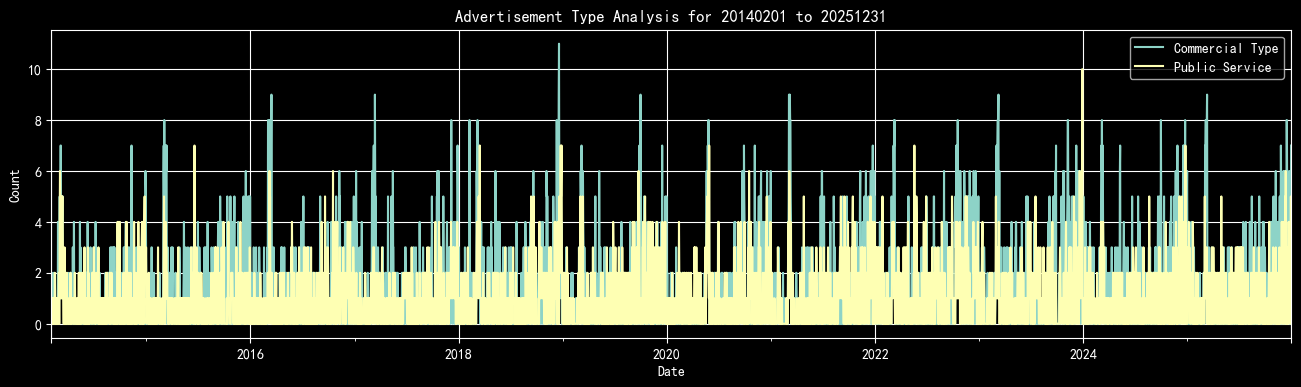

In [13]:
# ad_type plot

ad_type_counts = {} # date: {commercial_type: count, public_service: count}
# ad_type can be "商业广告", not "商业广告", "" (missing)
# Note that some AD_Industry_Output key is "YYYYMMDDVersion", we need to extract date only
for date_key in AD_Industry_Output:
    ad_type = AD_Industry_Output[date_key]["ad_type"]
    date_only = date_key[:8]  # Extract YYYYMMDD
    if date_only not in ad_type_counts:
        ad_type_counts[date_only] = {"commercial_type": 0, "public_service": 0}
    if ad_type == "商业广告":
        ad_type_counts[date_only]["commercial_type"] += 1
    elif ad_type != "商业广告" and ad_type != "":
        ad_type_counts[date_only]["public_service"] += 1

# Convert to DataFrame for plotting
dates = []
commercial_type_counts = []
public_service_counts = []
for date, counts in ad_type_counts.items():
    dates.append(datetime.strptime(date, "%Y%m%d"))
    commercial_type_counts.append(counts.get("commercial_type", 0))
    public_service_counts.append(counts.get("public_service", 0))
df = pd.DataFrame({
    "Date": dates,
    "Commercial Type": commercial_type_counts,
    "Public Service": public_service_counts
    })
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)
df.plot(kind="line", figsize=(16, 4))
plt.title(f"Advertisement Type Analysis for {Begin_date} to {End_date}")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.legend()

### Get Industry Daily Count

In [14]:
# Industry count
industry_count = {} # date: {industry_first_class1: count, industry_first_class2: count, ...}
for date_version, info in AD_Industry_Output.items():
    date_only = date_version[:8]  # Extract YYYYMMDD
    # count only commercial ads
    if info.get("ad_type", "") == "商业广告":
        industry_complete_list = info.get("industry", ["Unknown"]) # list of industries
        industry_first_class_set = set() # set of first class industries (to avoid duplicates)
        for industry_complete in industry_complete_list: # iterate over all industries
            industry_first_class = industry_complete.split("-")[0] if industry_complete != "Unknown" else "Unknown" # first class industry
            industry_first_class_set.add(industry_first_class)
        if date_only not in industry_count: # if date not in dict, create new dict
            industry_count[date_only] = {} # initialize date dict
        for industry_first_class in industry_first_class_set: # iterate over first class industries
            if industry_first_class not in industry_count[date_only]: # if industry not in date dict, set count to 1
                industry_count[date_only][industry_first_class] = 1
            else: # if industry in date dict, increment count
                industry_count[date_only][industry_first_class] += 1
    else: # ensure the date exists in the dict
        if date_only not in industry_count:
            industry_count[date_only] = {}

In [15]:
industry_count

{'20140201': {},
 '20140202': {},
 '20140203': {},
 '20140204': {},
 '20140205': {},
 '20140206': {},
 '20140207': {},
 '20140208': {'传媒': 1, '交通运输': 1},
 '20140209': {},
 '20140210': {'交通运输': 1},
 '20140211': {'交通运输': 1},
 '20140212': {'商贸零售': 1, '交通运输': 2},
 '20140213': {'交通运输': 1},
 '20140214': {},
 '20140215': {},
 '20140216': {},
 '20140217': {},
 '20140218': {},
 '20140219': {},
 '20140220': {},
 '20140221': {},
 '20140222': {},
 '20140223': {},
 '20140224': {},
 '20140225': {'银行': 4},
 '20140226': {},
 '20140227': {'银行': 1, '基础化工': 1, '农林牧渔': 1},
 '20140228': {},
 '20140301': {'计算机': 1},
 '20140302': {'电力设备': 1, '家用电器': 1, '非银金融': 1},
 '20140303': {'交通运输': 1, '煤炭': 2, '机械设备': 1, '汽车': 1, '银行': 2},
 '20140304': {'农林牧渔': 1, '食品饮料': 1, '交通运输': 1},
 '20140305': {'社会服务': 1, '机械设备': 1, '家用电器': 1, '非银金融': 1, '石油石化': 1},
 '20140306': {'食品饮料': 1, '银行': 1, '机械设备': 2, '交通运输': 2, '房地产': 2, '计算机': 1},
 '20140307': {'机械设备': 1,
  '汽车': 1,
  '社会服务': 1,
  '建筑装饰': 1,
  '建筑材料': 1,
  '食品饮料': 2,
  '

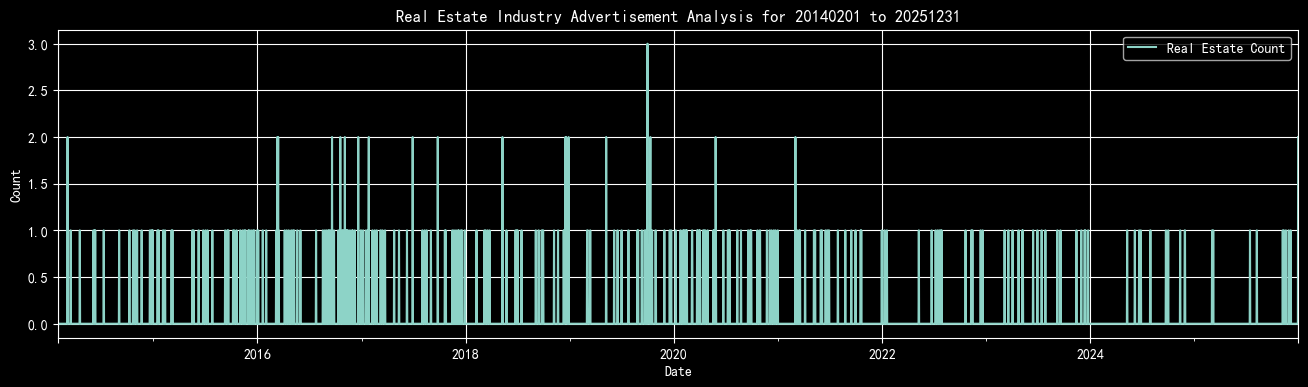

In [16]:
# "房地产" industry plot (absolute count)
real_estate_industry_counts = [] # date: count of "房地产" industry
dates = []
for date, counts in industry_count.items():
    dates.append(datetime.strptime(date, "%Y%m%d"))
    real_estate_industry_counts.append(counts.get("房地产", 0))
df = pd.DataFrame({
    "Date": dates,
    "Real Estate Count": real_estate_industry_counts
})
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)
df.plot(kind="line", figsize=(16, 4))
plt.title(f"Real Estate Industry Advertisement Analysis for {Begin_date} to {End_date}")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.legend()

### Get Monthly SoV (End of Month)

In [17]:
# Define an index: SoV (Share of Voice)
# SoV_{i, t} = (Number of industry i ads at month t) / (Total number of ads at month t)

# Calculate SoV for each industry and month use "industry_count"
# "industry_count" is like: {"YYYYMMDD": {industry1: count, industry2: count, ...}, ...}
# Some date may be {}, which means there is no ad

def Calculate_SOV(industry_count):
    """
    Calculate Share of Voice (SoV) for each industry by month.
    
    Parameters:
    -----------
    industry_count : dict
        Dictionary in format {"YYYYMMDD": {industry1: count, industry2: count, ...}, ...}
        Some dates may have empty dictionaries (no ads)
    
    Returns:
    --------
    dict
        Dictionary in format {"YYYYMM": {industry1: SoV, industry2: SoV, ...}, ...}
        SoV values are between 0 and 1
    """
    
    # Step 1: Aggregate data by month
    monthly_data = {}
    
    for date_str, day_data in industry_count.items():
        # Extract year and month (first 6 characters)
        month_key = date_str[:6]
        
        # Initialize month entry if it doesn't exist
        if month_key not in monthly_data:
            monthly_data[month_key] = {}
        
        # Sum up counts for each industry for this day
        for industry, count in day_data.items():
            monthly_data[month_key][industry] = monthly_data[month_key].get(industry, 0) + count
    
    # Step 2: Calculate SoV for each month
    sov_results = {}
    
    for month, month_data in monthly_data.items():
        # Calculate total ads for the month
        total_ads = sum(month_data.values())
        
        # Skip months with no ads
        if total_ads == 0:
            sov_results[month] = {}
            continue
        
        # Calculate SoV for each industry
        monthly_sov = {}
        for industry, count in month_data.items():
            monthly_sov[industry] = round(count / total_ads, 3)
        
        sov_results[month] = monthly_sov
    
    return sov_results


# Alternative function that returns the same data but sorted by month
# def calculate_sov_sorted(industry_count):
#     """
#     Calculate Share of Voice (SoV) for each industry by month, sorted chronologically.
#     """
#     sov_results = calculate_sov(industry_count)
    
#     # Sort months chronologically
#     sorted_months = sorted(sov_results.keys())
#     sorted_results = {month: sov_results[month] for month in sorted_months}
    
#     return sorted_results


# # Alternative function that includes all industries even in months where they have 0 ads
# def calculate_sov_complete(industry_count):
#     """
#     Calculate SoV including all industries with 0 for months where they don't appear.
#     """
#     # First, get all unique industries across all months
#     all_industries = set()
#     for day_data in industry_count.values():
#         all_industries.update(day_data.keys())
    
#     # Calculate basic SoV
#     sov_results = calculate_sov(industry_count)
    
#     # Add 0 for missing industries in each month
#     for month_data in sov_results.values():
#         for industry in all_industries:
#             if industry not in month_data:
#                 month_data[industry] = 0.0
    
#     return sov_results

sov_monthly_data = Calculate_SOV(industry_count)

In [18]:
sov_monthly_data

{'201402': {'传媒': 0.067,
  '交通运输': 0.4,
  '商贸零售': 0.067,
  '银行': 0.333,
  '基础化工': 0.067,
  '农林牧渔': 0.067},
 '201403': {'计算机': 0.084,
  '电力设备': 0.048,
  '家用电器': 0.024,
  '非银金融': 0.06,
  '交通运输': 0.072,
  '煤炭': 0.024,
  '机械设备': 0.072,
  '汽车': 0.06,
  '银行': 0.072,
  '农林牧渔': 0.012,
  '食品饮料': 0.072,
  '社会服务': 0.108,
  '石油石化': 0.012,
  '房地产': 0.036,
  '建筑装饰': 0.012,
  '建筑材料': 0.012,
  '综合': 0.024,
  '医药生物': 0.06,
  '电子': 0.024,
  '通信': 0.036,
  '钢铁': 0.024,
  '传媒': 0.024,
  '有色金属': 0.012,
  '美容护理': 0.012},
 '201404': {'传媒': 0.115,
  '计算机': 0.115,
  '汽车': 0.115,
  '食品饮料': 0.115,
  '非银金融': 0.154,
  '建筑装饰': 0.038,
  '农林牧渔': 0.115,
  '房地产': 0.038,
  '电子': 0.038,
  '交通运输': 0.038,
  '社会服务': 0.077,
  '有色金属': 0.038},
 '201405': {'汽车': 0.074,
  '农林牧渔': 0.074,
  '非银金融': 0.037,
  '轻工制造': 0.111,
  '传媒': 0.037,
  '商贸零售': 0.037,
  '机械设备': 0.037,
  '电子': 0.037,
  '银行': 0.296,
  '通信': 0.074,
  '计算机': 0.111,
  '交通运输': 0.037,
  '社会服务': 0.037},
 '201406': {'银行': 0.128,
  '非银金融': 0.043,
  '房地产': 0.064,
  '综合': 0

In [19]:
# Get SoV DataFrame for every level 1 industry (Option1: by using function `Calculate_SOV`)
# The all level 1 industry list is "SW_SECTOR_LEVEL_1_List"
# `sov_data` is like: {"YYYYMM": {industry1: SoV, industry2: SoV, ...}, ...}
# Note that the sov dataframe is used for quantitative analysis later
# In order to avoid future data, suppose we can get each month's sov data at the end of that month
# Also, the dataframe date range is from Begin_date to End_date (everyday with format YYYY-MM-DD), so we need to fill the missing dates with 0
sov_monthly_all_df = pd.DataFrame()
date_range = pd.date_range(start=Begin_date, end=End_date)
for single_date in date_range:
    month_end_date = single_date.replace(day=28) + timedelta(days=4)  # Why? to ensure we are in the next month
    month_end_date = month_end_date - timedelta(days=month_end_date.day)  # last day of the month
    if single_date != month_end_date: # set none values for non end of month dates
        row_data = {"date": single_date.strftime("%Y-%m-%d")}
        for industry in SW_SECTOR_LEVEL_1_List:
            row_data[industry] = 0
    else:
        year_month = single_date.strftime("%Y%m")
        sov_dict_for_month = sov_monthly_data.get(year_month, {})
        row_data = {"date": single_date.strftime("%Y-%m-%d")}
        for industry in SW_SECTOR_LEVEL_1_List:
            row_data[industry] = sov_dict_for_month.get(industry, 0.0)
    sov_monthly_all_df = pd.concat([sov_monthly_all_df, pd.DataFrame([row_data])], ignore_index=True)
sov_monthly_all_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
1,2014-02-02,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
2,2014-02-03,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
3,2014-02-04,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
4,2014-02-05,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
4348,2025-12-28,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
4349,2025-12-29,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00
4350,2025-12-30,0.000,0.000,0.0,0.00,0.000,0.000,0.0,0.000,0.0,...,0.000,0.00,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.00


In [20]:
# Get SoV DataFrame for every level 1 industry (only month end dates)
sov_monthly_df = pd.DataFrame()
date_range = pd.date_range(start=Begin_date, end=End_date)
for single_date in date_range:
    month_end_date = single_date.replace(day=28) + timedelta(days=4)  # Why? to ensure we are in the next month
    month_end_date = month_end_date - timedelta(days=month_end_date.day)  # last day of the month
    if single_date == month_end_date:
        year_month = single_date.strftime("%Y%m")
        sov_dict_for_month = sov_monthly_data.get(year_month, {})
        row_data = {"date": single_date.strftime("%Y-%m-%d")}
        for industry in SW_SECTOR_LEVEL_1_List:
            row_data[industry] = sov_dict_for_month.get(industry, 0.0)
        sov_monthly_df = pd.concat([sov_monthly_df, pd.DataFrame([row_data])], ignore_index=True)
sov_monthly_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-28,0.067,0.067,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.00,0.000,0.067,0.000,0.000,0.000,0.000,0.000
1,2014-03-31,0.012,0.000,0.024,0.012,0.024,0.060,0.024,0.072,0.000,...,0.048,0.072,0.00,0.084,0.024,0.036,0.024,0.012,0.000,0.012
2,2014-04-30,0.115,0.000,0.000,0.038,0.038,0.115,0.000,0.115,0.000,...,0.000,0.000,0.00,0.115,0.115,0.000,0.000,0.000,0.000,0.000
3,2014-05-31,0.074,0.000,0.000,0.000,0.037,0.074,0.000,0.000,0.000,...,0.000,0.037,0.00,0.111,0.037,0.074,0.000,0.000,0.000,0.000
4,2014-06-30,0.064,0.021,0.000,0.000,0.021,0.064,0.000,0.000,0.000,...,0.000,0.043,0.00,0.085,0.106,0.128,0.000,0.000,0.021,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,2025-08-31,0.058,0.000,0.000,0.019,0.019,0.019,0.019,0.077,0.000,...,0.058,0.038,0.00,0.058,0.000,0.058,0.000,0.000,0.000,0.038
139,2025-09-30,0.031,0.000,0.000,0.000,0.078,0.031,0.000,0.078,0.000,...,0.109,0.078,0.00,0.094,0.047,0.000,0.000,0.016,0.016,0.016
140,2025-10-31,0.056,0.014,0.000,0.000,0.099,0.028,0.028,0.127,0.028,...,0.056,0.000,0.00,0.056,0.042,0.014,0.000,0.042,0.000,0.000
141,2025-11-30,0.042,0.021,0.000,0.000,0.073,0.125,0.000,0.042,0.021,...,0.010,0.042,0.01,0.052,0.083,0.010,0.010,0.010,0.010,0.010


In [21]:
# Get sov_z_score DataFrame for every level 1 industry (only month end dates)
# SOV Z-score values (window size 12 months)
# Sov Z-score_{i, t} = (SoV_{i, t} - mean(SoV_{i, t-12})) / std(SoV_{i, t-12})
sov_z_score_monthly_df = sov_monthly_df.copy()
sov_z_score_monthly_df.set_index("date", inplace=True)
for industry in SW_SECTOR_LEVEL_1_List:
    sov_z_score_monthly_df[industry] = sov_z_score_monthly_df[industry].rolling(window=12).apply(
        lambda x: (x.iloc[-1] - x.mean()) / x.std() if x.std() != 0 else 0, raw=False
    )
sov_z_score_monthly_df.reset_index(inplace=True)
sov_z_score_monthly_df.fillna(0, inplace=True)
sov_z_score_monthly_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2014-03-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2014-04-30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2014-05-31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2014-06-30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,2025-08-31,0.890071,-0.620520,-0.427412,1.220676,-0.592918,-0.360561,0.171469,-0.344973,-0.768410,...,0.264977,0.688443,-0.606372,-0.509370,-1.005226,0.119381,-0.528191,-0.634819,-0.630977,0.522899
139,2025-09-30,0.042894,-0.559899,-0.427412,-0.622464,1.906171,-0.108075,-0.721466,-0.304870,-0.768410,...,1.446226,2.370996,-0.504921,0.355982,0.961187,-0.474329,-0.405388,0.280173,0.729113,-0.280181
140,2025-10-31,0.712197,0.043750,-0.427412,-0.622464,2.003457,-0.247243,0.739435,0.299507,0.803550,...,-0.073142,-1.279291,-0.504921,-0.599857,0.623692,-0.141403,-0.405388,2.165225,-0.643335,-0.766393
141,2025-11-30,0.171938,0.298850,-0.427412,-0.622464,1.047867,1.704100,-0.734407,-0.761780,0.354859,...,-1.201637,0.525177,0.676701,-0.755976,1.809841,0.009849,1.074311,-0.069673,0.145837,-0.422403


In [22]:
# Get full sov_z_score DataFrame for every level 1 industry (every date) based on monthly sov_z_score
sov_z_score_monthly_all_df = pd.DataFrame()
date_range = pd.date_range(start=Begin_date, end=End_date)
for single_date in date_range:
    month_end_date = single_date.replace(day=28) + timedelta(days=4)  # Why? to ensure we are in the next month
    month_end_date = month_end_date - timedelta(days=month_end_date.day)  # last day of the month
    if single_date != month_end_date: # set none values for non end of month dates
        row_data = {"date": single_date.strftime("%Y-%m-%d")}
        for industry in SW_SECTOR_LEVEL_1_List:
            row_data[industry] = 0
    else:
        date_str = single_date.strftime("%Y-%m-%d")
        sov_z_score_row = sov_z_score_monthly_df[sov_z_score_monthly_df["date"] == date_str]
        row_data = {"date": date_str}
        for industry in SW_SECTOR_LEVEL_1_List:
            if not sov_z_score_row.empty:
                row_data[industry] = float(sov_z_score_row[industry].values[0])
            else:
                row_data[industry] = 0
    sov_z_score_monthly_all_df = pd.concat([sov_z_score_monthly_all_df, pd.DataFrame([row_data])], ignore_index=True)
sov_z_score_monthly_all_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2014-02-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2014-02-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2014-02-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2014-02-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4348,2025-12-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4349,2025-12-29,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4350,2025-12-30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [23]:
# Set all sov_z_score_all_df values to larger or equal than 2 to 1 (otherwise 0)
sov_z_score_monthly_all_df_larger2 = sov_z_score_monthly_all_df.copy()
for industry in SW_SECTOR_LEVEL_1_List:
    sov_z_score_monthly_all_df_larger2[industry] = sov_z_score_monthly_all_df_larger2[industry].apply(lambda x: 1 if x >= 2 else 0)
sov_z_score_monthly_all_df_larger2

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2014-02-02,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2014-02-03,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2014-02-04,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2014-02-05,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4348,2025-12-28,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4349,2025-12-29,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4350,2025-12-30,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Get Daily SoV (With Sliding Window)

In [24]:
# Convert dict industry_count to Dataframe (full daily data)
# 1. Create DataFrame from Dict
industry_count_df = pd.DataFrame.from_dict(industry_count, orient='index')

# 2. Convert the current index to Datetime objects
# This is crucial so it matches the format of the date_range we are about to create.
industry_count_df.index = pd.to_datetime(industry_count_df.index)

# 3. [NEW STEP] Create the full Date Range and Reindex Rows
# This generates every day between start and end.
full_date_range = pd.date_range(start=Begin_date, end=End_date)

# reindex(index=...) aligns the rows. 
# Any date in 'full_date_range' not in the dataframe is created and filled with 0.
industry_count_df = industry_count_df.reindex(index=full_date_range, fill_value=0)

# 4. Align with your full Industry List (Reindex Columns)
# This ensures all industry columns exist, filling missing ones with 0.
industry_count_df = industry_count_df.reindex(columns=SW_SECTOR_LEVEL_1_List, fill_value=0)

# 5. Final Cleanup
industry_count_df.index.name = 'date'   # Name the index
industry_count_df = industry_count_df.reset_index() # Move date to column

# Optional: Ensure columns are integers (reindexing often introduces floats for NaNs)
industry_count_df = industry_count_df.fillna(0)
industry_count_df.iloc[:, 1:] = industry_count_df.iloc[:, 1:].astype(int)
industry_count_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014-02-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014-02-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014-02-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014-02-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4348,2025-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4349,2025-12-29,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4350,2025-12-30,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# Get sov dataframe last 30 days (full)
# 1. Setup: Ensure 'date' is the index
# This is required for the rolling window to work sequentially on rows
# If 'date' is currently a column, we set it as the index temporarily
if 'date' in industry_count_df.columns:
    industry_count_df = industry_count_df.set_index('date')

# 2. Define your window size 'n'
n = 30  # Example: Last 30 days including today

# 3. Calculate the Numerator: Rolling sum for each industry
# min_periods=1 ensures you get values for the first few days (before n days have passed)
# If you want strictly 'NaN' until day n, remove min_periods=1
industry_rolling_sum = industry_count_df.rolling(window=n, min_periods=1).sum()

# 4. Calculate the Denominator: Total sum of all industries for that window
# We sum across the columns (axis=1) for each day
total_rolling_sum = industry_rolling_sum.sum(axis=1)

# 5. Calculate SOV: Divide each industry's rolling sum by the total
# axis=0 aligns the division by the index (date)
sov_daily_df = industry_rolling_sum.div(total_rolling_sum, axis=0)

# 6. Cleanup: Handle division by zero
# If a specific window had 0 total activity, the result is NaN. We fill it with 0.
sov_daily_df = sov_daily_df.fillna(0)

# 7. (Optional) Reset index to make date a column again
sov_daily_df = sov_daily_df.reset_index()

sov_daily_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
1,2014-02-02,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
2,2014-02-03,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,2014-02-04,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
4,2014-02-05,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0.015385,0.015385,0.0,0.023077,0.038462,0.030769,0.0,0.046154,0.0,...,0.092308,0.023077,0.0,0.092308,0.015385,0.038462,0.0,0.0,0.0,0.015385
4348,2025-12-28,0.015625,0.015625,0.0,0.023438,0.039062,0.031250,0.0,0.046875,0.0,...,0.093750,0.023438,0.0,0.093750,0.015625,0.039062,0.0,0.0,0.0,0.015625
4349,2025-12-29,0.015038,0.015038,0.0,0.022556,0.037594,0.037594,0.0,0.045113,0.0,...,0.090226,0.022556,0.0,0.090226,0.015038,0.037594,0.0,0.0,0.0,0.015038
4350,2025-12-30,0.014599,0.014599,0.0,0.021898,0.036496,0.043796,0.0,0.043796,0.0,...,0.087591,0.021898,0.0,0.087591,0.014599,0.036496,0.0,0.0,0.0,0.014599


In [26]:
sov_z_score_daily_df = sov_daily_df.copy()
sov_z_score_daily_df.set_index("date", inplace=True)
for industry in SW_SECTOR_LEVEL_1_List:
    sov_z_score_daily_df[industry] = sov_z_score_daily_df[industry].rolling(365).apply(
        lambda x: (x.iloc[-1] - x.mean()) / x.std() if x.std() != 0 else 0, raw=False
    )
sov_z_score_daily_df.reset_index(inplace=True)
sov_z_score_daily_df.fillna(0, inplace=True)
sov_z_score_daily_df

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2014-02-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2014-02-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2014-02-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2014-02-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,-0.719239,0.072806,-0.318243,1.334525,-0.029976,-0.344219,-0.773979,-0.908006,-0.719337,...,1.256752,-0.455186,-0.488123,0.355051,-0.572555,1.750853,-0.522077,-0.745969,-0.729066,-0.251497
4348,2025-12-28,-0.710160,0.084126,-0.318243,1.356728,-0.009069,-0.328031,-0.773979,-0.895434,-0.716238,...,1.309272,-0.441093,-0.488123,0.403215,-0.564395,1.779305,-0.522077,-0.743745,-0.729066,-0.244545
4349,2025-12-29,-0.736640,0.048357,-0.318243,1.275270,-0.053855,-0.152809,-0.773979,-0.922617,-0.712990,...,1.203354,-0.483941,-0.488123,0.289941,-0.587605,1.672933,-0.522077,-0.741390,-0.729066,-0.267534
4350,2025-12-30,-0.756736,0.021060,-0.318243,1.213148,-0.087062,0.018393,-0.773979,-0.942777,-0.709852,...,1.124143,-0.516612,-0.488123,0.206219,-0.605180,1.592129,-0.522077,-0.739128,-0.729066,-0.285131


In [27]:
# Set all sov_z_score_all_df values to larger or equal than 2 to 1 (otherwise 0)
# Define conditions and choices
sov_z_score_daily_all_df_larger2 = sov_z_score_daily_df.copy()
sov_z_score_daily_all_df_larger2 = sov_z_score_daily_all_df_larger2.set_index("date")
conditions = [
    (sov_z_score_daily_all_df_larger2 >= 2.0),   # Condition for 1
    (sov_z_score_daily_all_df_larger2 <= -2.0)   # Condition for -1
]
choices = [1, -1]

# Create new DataFrame using select
# default=0 handles the "Otherwise 0" case
sov_z_score_daily_all_df_larger2 = pd.DataFrame(
    np.select(conditions, choices, default=0),
    index=sov_z_score_daily_all_df_larger2.index,
    columns=sov_z_score_daily_all_df_larger2.columns
)

sov_z_score_daily_all_df_larger2.reset_index(inplace=True)
sov_z_score_daily_all_df_larger2

,date,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
0,2014-02-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2014-02-02,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2014-02-03,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2014-02-04,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2014-02-05,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4347,2025-12-27,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4348,2025-12-28,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4349,2025-12-29,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4350,2025-12-30,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
def Signal2Position(signal_df, frequency=1):
    """
    We change our position daily (default). Now, we get position dataframe (0 or 1) based on the signals.
    (Explanation: position = 1 means we hold the stock, position = 0 means we do not hold the stock)
    (If the instrument can be shorted, position = -1 means we short the stock)
    (Note that we suppose the instruments cannot be shorted in this example.)

    In order to avoid future data leakage, we will shift the signals by one day when calculating weights.
    (i.e. the weight on day t is based on the signal generated on day t-1)

    In the position changing day, we will take the full position according to the signal.
    There are 9 possible situations:
    Previous signal = 0.0, Current signal = 1.0  => position = 1.0 (buy)
    Previous signal = 0.0, Current signal = -1.0 => position = 0.0 (do nothing, cannot short)
    Previous signal = 0.0, Current signal = 0.0  => position = 0.0 (do nothing)
    Previous signal = 1.0, Current signal = 1.0  => position = 1.0 (hold)
    Previous signal = 1.0, Current signal = -1.0 => position = 0.0 (sell)
    Previous signal = 1.0, Current signal = 0.0  => position = 1.0 (hold)
    Previous signal = -1.0, Current signal = 1.0 => position = 1.0 (buy)
    Previous signal = -1.0, Current signal = -1.0 => position = 0.0 (do nothing, cannot short)
    Previous signal = -1.0, Current signal = 0.0 => position = 0.0 (do nothing, cannot short)

    More generally, if we change the position weekly (or other frequency), we can follow the same logic.
    First, add a new column 'week' to the signals DataFrame, which indicates the week number of each date.
    Then, we keep only the signals on each position changing day (e.g., Monday) (After the signals are shifted).
    Then, we can follow the same logic as above to calculate the positions.
    Finally, we reindex the positions DataFrame to match the original signals DataFrame, forward filling the positions for the days in between.
    """
    signals_shifted = signal_df.shift(frequency).fillna(0.0)
    # We change our position daily. Now, we get position dataframe (0 or 1) based on the signals.

    positions = signals_shifted.copy()
    positions[(signals_shifted == 0.0) & (signal_df == 1.0)] = 1.0  # buy
    positions[(signals_shifted == 0.0) & (signal_df == -1.0)] = 0.0  # do nothing, cannot short
    positions[(signals_shifted == 0.0) & (signal_df == 0.0)] = 0.0  # do nothing
    positions[(signals_shifted == 1.0) & (signal_df == 1.0)] = 1.0  # hold
    positions[(signals_shifted == 1.0) & (signal_df == -1.0)] = 0.0  # sell
    positions[(signals_shifted == 1.0) & (signal_df == 0.0)] = 1.0  # hold
    positions[(signals_shifted == -1.0) & (signal_df == 1.0)] = 1.0  # buy
    positions[(signals_shifted == -1.0) & (signal_df == -1.0)] = 0.0  # do nothing, cannot short
    positions[(signals_shifted == -1.0) & (signal_df == 0.0)] = 0.0  # do nothing, cannot short
    
    return positions

def Position2Fee(position_df, buy_fee=0.001, sell_fee=0.001):
    """
    Also, we can get fee DataFrame based on the position changes.
    If the position changes (from 0 to 1, or from 1 to 0), we will incur a transaction fee.
    Suppose the transaction fee is 0.1% (0.001) for both buy and sell.
    """
    fee = pd.DataFrame(0.0, index=position_df.index, columns=position_df.columns)
    # Identify where positions change
    position_buy_changes = position_df.diff() == 1.0
    position_sell_changes = position_df.diff() == -1.0

    # Apply fees for buys and sells
    fee[position_buy_changes] = buy_fee
    fee[position_sell_changes] = sell_fee
    
    return fee

In [29]:
sov_z_score_daily_all_df_larger2_index = sov_z_score_daily_all_df_larger2.set_index("date")
sov_z_score_daily_all_df_larger2_position = Signal2Position(sov_z_score_daily_all_df_larger2_index)
sov_z_score_daily_all_df_larger2_position

,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,轻工制造,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
date,,,,,,,,,,,,,,,,,,,,,
2014-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
sov_z_score_daily_all_df_larger2_fee = Position2Fee(sov_z_score_daily_all_df_larger2_position)
sov_z_score_daily_all_df_larger2_fee

,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,轻工制造,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
date,,,,,,,,,,,,,,,,,,,,,
2014-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
def Position2Weight(position_df):
    """
    After getting the positions DataFrame, we can calculate the weights DataFrame.
    The weights are calculated based on the positions and the number of stocks held.

    In realistic, we think about the following:
    1. At the position changing day, the long position instruments may have overlapping elements with the previous long position instruments.
    In this case, we only need to buy the new long position instruments, and sell the the instruments that are no longer in the long position.
    Also, we need to rebalance the weights of the held instruments.
    (In this example, we assume we always take full position according to the signals, so the weights are equal weighted among the held instruments.)
    """
    num_stocks_held = position_df.sum(axis=1)
    weights = position_df.div(num_stocks_held, axis=0).fillna(0.0)
    return weights

In [32]:
sov_z_score_daily_all_df_larger2_weight = Position2Fee(sov_z_score_daily_all_df_larger2_position)
sov_z_score_daily_all_df_larger2_weight

,农林牧渔,基础化工,钢铁,有色金属,电子,汽车,家用电器,食品饮料,纺织服饰,轻工制造,...,电力设备,机械设备,国防军工,计算机,传媒,通信,煤炭,石油石化,环保,美容护理
date,,,,,,,,,,,,,,,,,,,,,
2014-02-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-02-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Backtest

In [33]:
# Get benchmark return data
benchmark_roi_all_df_index = benchmark_roi_all_df.set_index("date")
HS_300 = benchmark_roi_all_df_index["HS300"]
CS_500 = benchmark_roi_all_df_index["CSI500"]
CS_1000 = benchmark_roi_all_df_index["CSI1000"]

"""
We now have:
1. positions DataFrame: indicates whether we hold each stock on each day (1.0 for hold, 0.0 for not hold).
2. fee DataFrame: indicates the transaction fee incurred on each stock on each day (0.0 if no transaction, otherwise the fee rate).
3. weights DataFrame: indicates the weight of each stock in the portfolio on each day (equal weighted among held stocks).
These DataFrames can be used for backtesting the trading strategy.

Now we can calculate the daily portfolio returns based on the weights and price returns.
The daily portfolio return is calculated as the sum of the product of weights and price returns for all stocks.
"""
industry_level1_roi_all_df_index = industry_level1_roi_all_df.set_index("date")
portfolio_return_df = ((
    sov_z_score_daily_all_df_larger2_weight 
    * (industry_level1_roi_all_df_index - sov_z_score_daily_all_df_larger2_fee))
    .sum(axis=1))
portfolio_return_df

date
2014-02-01    0.000000
2014-02-02    0.000000
2014-02-03    0.000000
2014-02-04    0.000000
2014-02-05    0.000000
                ...   
2025-12-27    0.000000
2025-12-28    0.000000
2025-12-29    0.000002
2025-12-30    0.000000
2025-12-31    0.000000
Length: 4352, dtype: float64

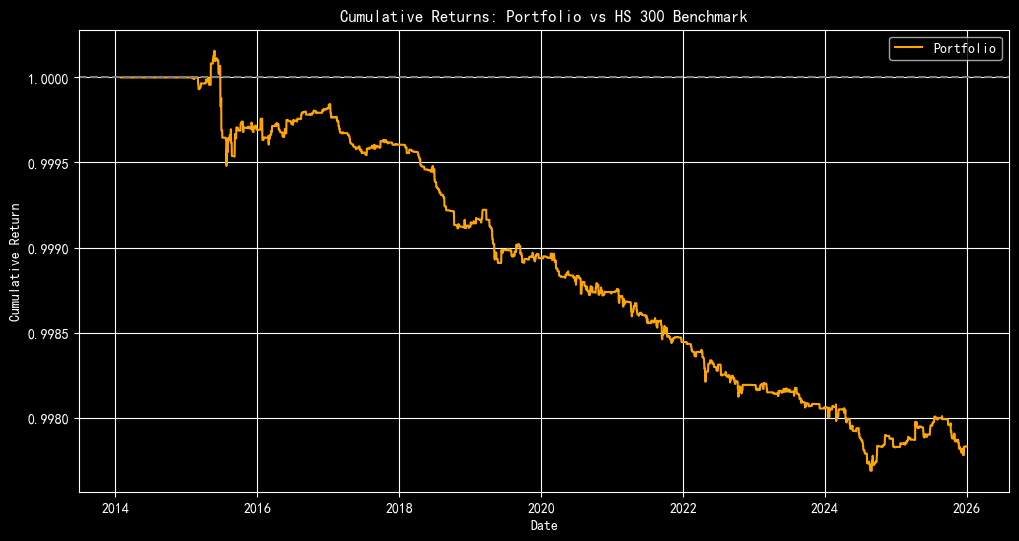

In [40]:
# Then, plot the cumulative returns of the portfolio and benchmark for comparison.
cumulative_portfolio_return = (1 + portfolio_return_df).cumprod()
cumulative_HS300_return = (1 + HS_300).cumprod()
cumulative_CS_500_return = (1 + CS_500).cumprod()
cumulative_CS_1000_return = (1 + CS_1000).cumprod()
plt.figure(figsize=(12, 6))
plt.plot(cumulative_portfolio_return.index, cumulative_portfolio_return, label='Portfolio', color="orange")
# plt.plot(cumulative_HS300_return.index, cumulative_HS300_return, label='HS 300 Benchmark', color="r")
# plt.plot(cumulative_CS_500_return.index, cumulative_CS_500_return, label='CS 500 Benchmark', color="g")
# plt.plot(cumulative_CS_1000_return.index, cumulative_CS_1000_return, label='CS 1000 Benchmark', color="b")
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Returns: Portfolio vs HS 300 Benchmark')
plt.axhline(y=1, color="grey", linestyle="--")
plt.legend()
plt.grid(True)
plt.show()

### SOV Visualization

In [35]:
def Plot_SOV_Industry_DF(industry_name, sw_sector_path_map, sov_df, sov_moving_avg_win_size, Begin_date, End_date):
    """
    - Plot Share of Voice (SoV), Z-score and PnL for a given industry over time.
    - industry_name: str, name of the industry to plot
    - sov_df: sov dataframe
    - sov_moving_avg_win_size: int, window size for moving average of SoV
    - pnl_data: list, PnL data corresponding to the date range
    """
    pnl_data_df = Get_Index_ROI(industry_name, sw_sector_path_map, Begin_date, End_date)
    pnl_data = list((1 + pnl_data_df['ROI']).cumprod())
    # Add SOV Z-score values (window size 12 months)
    # Sov Z-score_{i, t} = (SoV_{i, t} - mean(SoV_{i, t-12})) / std(SoV_{i, t-12})
    sov_data_df = sov_df[["date", industry_name]].copy()
    industry_series = sov_data_df[industry_name]
    
    sov_name = f"{industry_name} SoV"
    sov_data_df = sov_data_df.rename(columns={industry_name: sov_name})
    sov_ma_name = f"{industry_name} SoV MA{sov_moving_avg_win_size}"
    sov_data_df[sov_ma_name] = industry_series.rolling(window=sov_moving_avg_win_size).mean().fillna(0)
    
    zscore_name = f"{industry_name} SoV Z-score"
    # Step A: Calculate Rolling Mean and Std for window 12
    r_mean = industry_series.rolling(window=365).mean()
    r_std = industry_series.rolling(window=365).std()

    # Step B: Apply Formula: (Current Value - Rolling Mean) / Rolling Std
    # We use fillna(0) to handle cases where std is 0 (avoiding division by zero errors)
    sov_data_df[zscore_name] = ((industry_series - r_mean) / r_std).fillna(0)

    df_sov = sov_data_df[["date", sov_name, sov_ma_name]]
    df_sov_zscore = sov_data_df[["date", zscore_name]]
    df_daily_pnl = pd.DataFrame({
        "date": pd.date_range(start=Begin_date, end=End_date),
        "PnL": pnl_data
    })

    # Create a figure with multiple subplots
    _, axes = plt.subplots(3, 1, figsize=(16, 6))

    # Prepare data (do this once, not repeatedly)
    df_sov.set_index("date", inplace=True)
    df_sov.sort_index(inplace=True)

    df_sov_zscore.set_index("date", inplace=True)
    df_sov_zscore.sort_index(inplace=True)

    # Plot 1: Share of Voice
    ax1 = axes[0]
    df_sov.plot(kind="line", ax=ax1)
    ax1.set_title(f"{industry_name} Share of Voice (SoV) from {Begin_date} to {End_date}")
    ax1.set_ylabel("SoV")
    ax1.grid(True)
    ax1.legend()

    # Plot 2: Daily PnL
    ax2 = axes[1]
    df_daily_pnl.set_index("date", inplace=True)
    df_daily_pnl.sort_index(inplace=True)
    df_daily_pnl.plot(kind="line", ax=ax2, color='green')
    ax2.set_title(f"Daily PnL from {Begin_date} to {End_date}")
    ax2.set_xlabel("date")
    ax2.set_ylabel("PnL")
    ax2.grid(True)
    ax2.legend()

    # Plot 3: Z-score
    ax3 = axes[2]
    df_sov_zscore.plot(kind="line", ax=ax3, color='orange')
    ax3.set_title(f"{industry_name} Share of Voice (SoV) Z-score from {Begin_date} to {End_date}")
    ax3.set_xlabel("date")
    ax3.set_ylabel("SoV Z-score")
    ax3.grid(True)
    ax3.legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()

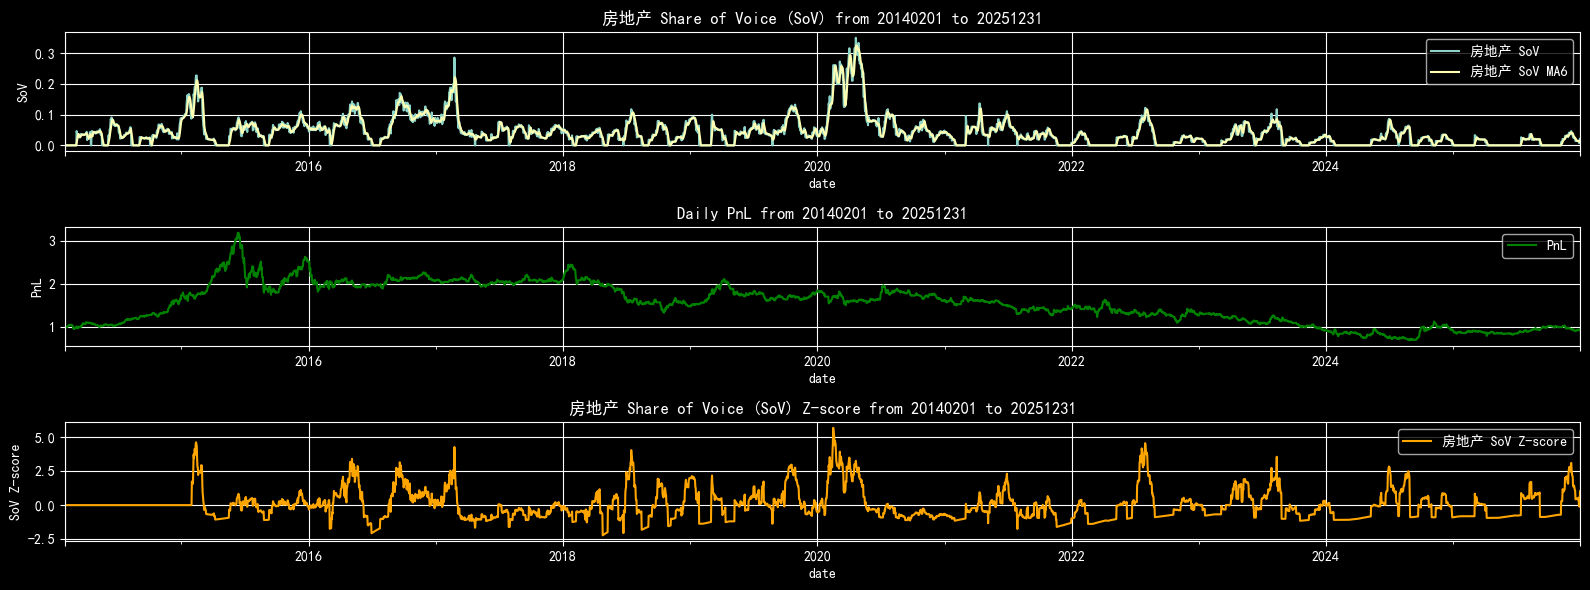

In [36]:
Plot_SOV_Industry_DF(industry_name="房地产", sw_sector_path_map=SW_SECTOR_PATH_MAPPING, sov_df=sov_daily_df, sov_moving_avg_win_size=6, Begin_date=Begin_date, End_date=End_date)

In [37]:
def Plot_SOV_Industry(industry_name, sw_sector_path_map, sov_data, sov_moving_avg_win_size, Begin_date, End_date):
    """
    - Plot Share of Voice (SoV), Z-score and PnL for a given industry over time.
    - industry_name: str, name of the industry to plot
    - sov_data: dict, output from Calculate_SOV function
    - sov_moving_avg_win_size: int, window size for moving average of SoV
    - pnl_data: list, PnL data corresponding to the date range
    """
    pnl_data_df = Get_Index_ROI(industry_name, sw_sector_path_map, Begin_date, End_date)
    pnl_data = list((1 + pnl_data_df['ROI']).cumprod())
    # Add SOV Z-score values (window size 12 months)
    # Sov Z-score_{i, t} = (SoV_{i, t} - mean(SoV_{i, t-12})) / std(SoV_{i, t-12})
    industry_sov = [] # date: SoV of the industry
    dates = []
    for date, counts in sov_data.items():
        dates.append(datetime.strptime(date, "%Y%m"))
        industry_sov.append(counts.get(industry_name, 0))
    industry_sov_moving_avg = pd.Series(industry_sov).rolling(window=sov_moving_avg_win_size).mean()
    industry_sov_zscore = pd.Series(industry_sov).rolling(window=12).apply(lambda x: (x.iloc[-1] - x.mean()) / x.std() if x.std() != 0 else 0)
    df_sov = pd.DataFrame({
        "Date": dates,
        f"{industry_name} SoV": industry_sov,
        f"{industry_name} SoV MA{sov_moving_avg_win_size}": industry_sov_moving_avg
    })
    df_sov_zscore = pd.DataFrame({
        "Date": dates,
        f"{industry_name} SoV Z-score": industry_sov_zscore
    })
    df_daily_pnl = pd.DataFrame({
        "Date": pd.date_range(start=Begin_date, end=End_date),
        "PnL": pnl_data
    })

    # Create a figure with multiple subplots
    _, axes = plt.subplots(3, 1, figsize=(16, 6))

    # Prepare data (do this once, not repeatedly)
    df_sov.set_index("Date", inplace=True)
    df_sov.sort_index(inplace=True)

    df_sov_zscore.set_index("Date", inplace=True)
    df_sov_zscore.sort_index(inplace=True)

    # Plot 1: Share of Voice
    ax1 = axes[0]
    df_sov.plot(kind="line", ax=ax1, marker="o")
    ax1.set_title(f"{industry_name} Share of Voice (SoV) from {Begin_date} to {End_date}")
    ax1.set_ylabel("SoV")
    ax1.grid(True)
    ax1.legend()

    # Plot 2: Daily PnL
    ax2 = axes[1]
    df_daily_pnl.set_index("Date", inplace=True)
    df_daily_pnl.sort_index(inplace=True)
    df_daily_pnl.plot(kind="line", ax=ax2, color='green')
    ax2.set_title(f"Daily PnL from {Begin_date} to {End_date}")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("PnL")
    ax2.grid(True)
    ax2.legend()

    # Plot 3: Z-score
    ax3 = axes[2]
    df_sov_zscore.plot(kind="line", ax=ax3, marker="o", color='orange')
    ax3.set_title(f"{industry_name} Share of Voice (SoV) Z-score from {Begin_date} to {End_date}")
    ax3.set_xlabel("Date")
    ax3.set_ylabel("SoV Z-score")
    ax3.grid(True)
    ax3.legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()

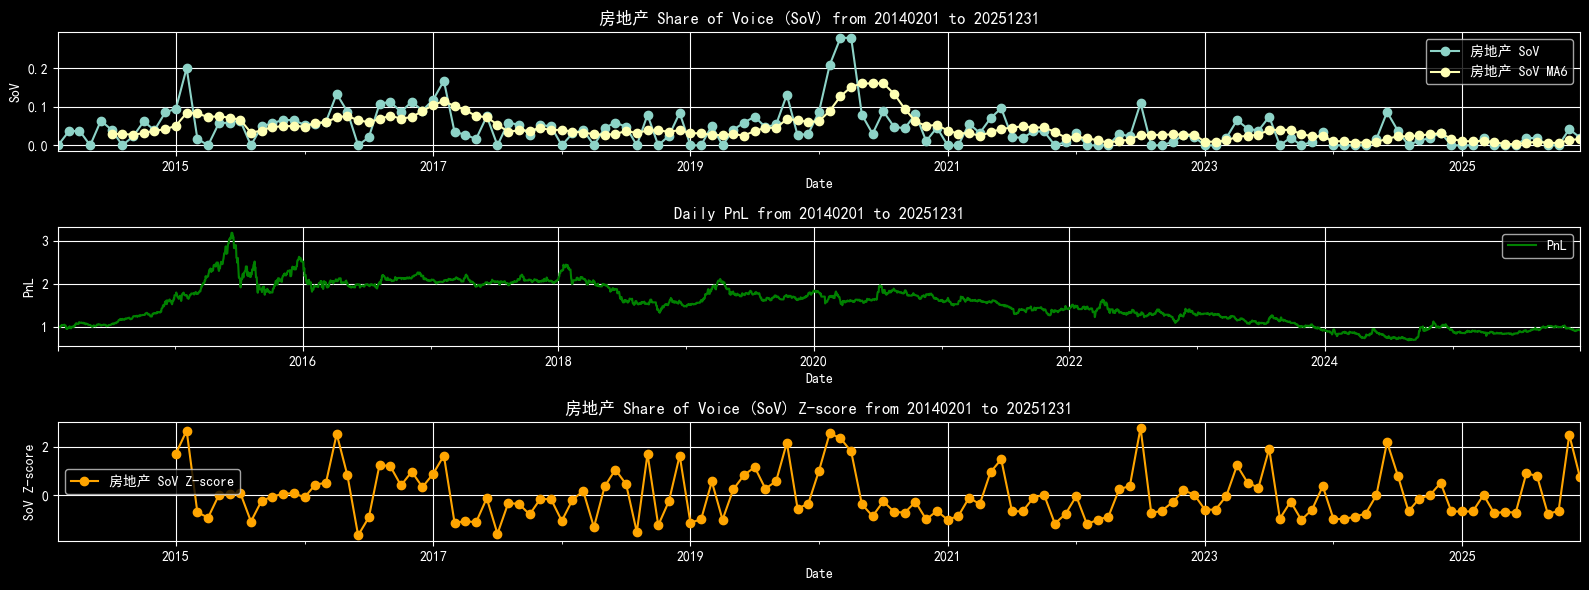

In [38]:
Plot_SOV_Industry(industry_name="房地产", sw_sector_path_map=SW_SECTOR_PATH_MAPPING, sov_data=sov_monthly_data, sov_moving_avg_win_size=6, Begin_date=Begin_date, End_date=End_date)